<a href="https://www.kaggle.com/code/skailshvenkat/fem-fdm?scriptVersionId=224783055" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import os
from tensorflow.keras.preprocessing import image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image  

dataset_path = '/kaggle/input/normal/NORMAL' 
image_size = (128, 128)  # Target image size

def load_images(dataset_path, image_size=(128, 128)):
    images = []
    for img_name in os.listdir(dataset_path):
        img_path = os.path.join(dataset_path, img_name)
        img = image.load_img(img_path, target_size=image_size)  
        img = image.img_to_array(img)  
        img = img / 255.0 
        images.append(img)
    return np.array(images)

images = load_images(dataset_path)


In [3]:
X_train, X_test = train_test_split(images, test_size=0.2, random_state=42)

In [4]:
from tensorflow.keras import layers, models

def res_block(x, filters, use_bn=True, dropout_rate=0.0):
    shortcut = x
    x = layers.Conv2D(filters, (3, 3), padding="same", activation="relu")(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    if dropout_rate > 0.0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Conv2D(filters, (3, 3), padding="same", activation=None)(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Add()([shortcut, x])
    x = layers.Activation("relu")(x)
    return x

def build_complex_encoder(input_shape=(128, 128, 3)):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), strides=2, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 64, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2D(128, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 128, use_bn=True, dropout_rate=0.1)

    x = layers.Flatten()(x)
    latent = layers.Dense(256, activation="relu")(x)

    return models.Model(inputs, latent, name="Complex_Encoder")



In [5]:
def build_complex_decoder(latent_dim=256, target_shape=(128, 128, 3)):
    inputs = layers.Input(shape=(latent_dim,))

    x = layers.Dense(16 * 16 * 128, activation="relu")(inputs)
    x = layers.Reshape((16, 16, 128))(x)

    x = layers.Conv2DTranspose(128, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 128, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2DTranspose(64, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 64, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2DTranspose(32, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2DTranspose(target_shape[-1], (3, 3), padding="same", activation="sigmoid")(x)

    return models.Model(inputs, x, name="Complex_Decoder")



In [6]:
def build_autoencoder(input_shape=(128, 128, 3)):
    encoder = build_complex_encoder(input_shape)
    decoder = build_complex_decoder(latent_dim=256, target_shape=input_shape)

    inputs = layers.Input(shape=input_shape)
    latent = encoder(inputs)
    reconstructed = decoder(latent)

    autoencoder = models.Model(inputs, reconstructed, name="Autoencoder")
    autoencoder.compile(optimizer="adam", loss="mean_squared_error")
    return autoencoder



In [7]:
autoencoder = build_autoencoder(input_shape=(128, 128, 3))
autoencoder.summary()

autoencoder.fit(
    X_train, X_train,
    validation_data=(X_test, X_test),
    epochs=67,
    batch_size=16,
)


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Complex_Encoder (Functional)         │ (None, 256)                 │       8,853,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Complex_Decoder (Functional)         │ (None, 128, 128, 3)         │       9,033,539 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,887,107 (68.23 MB)

 Trainable params: 17,884,675 (68.22 MB)

 Non-trainable params: 2,432 (9.50 KB)

Epoch 1/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 44s 257ms/step - loss: 0.0365 - val_loss: 0.0651
Epoch 2/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0141 - val_loss: 0.0374
Epoch 3/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0101 - val_loss: 0.0193
Epoch 4/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0086 - val_loss: 0.0127
Epoch 5/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0076 - val_loss: 0.0086
Epoch 6/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0069 - val_loss: 0.0072
Epoch 7/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0065 - val_loss: 0.0069
Epoch 8/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0061 - val_loss: 0.0063
Epoch 9/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0057 - val_loss: 0.0059
Epoch 10/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0055 - val_loss: 0.0068
Epoch 11/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0055 - val_loss: 0.0079
Epoch 12/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0

10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 468ms/step


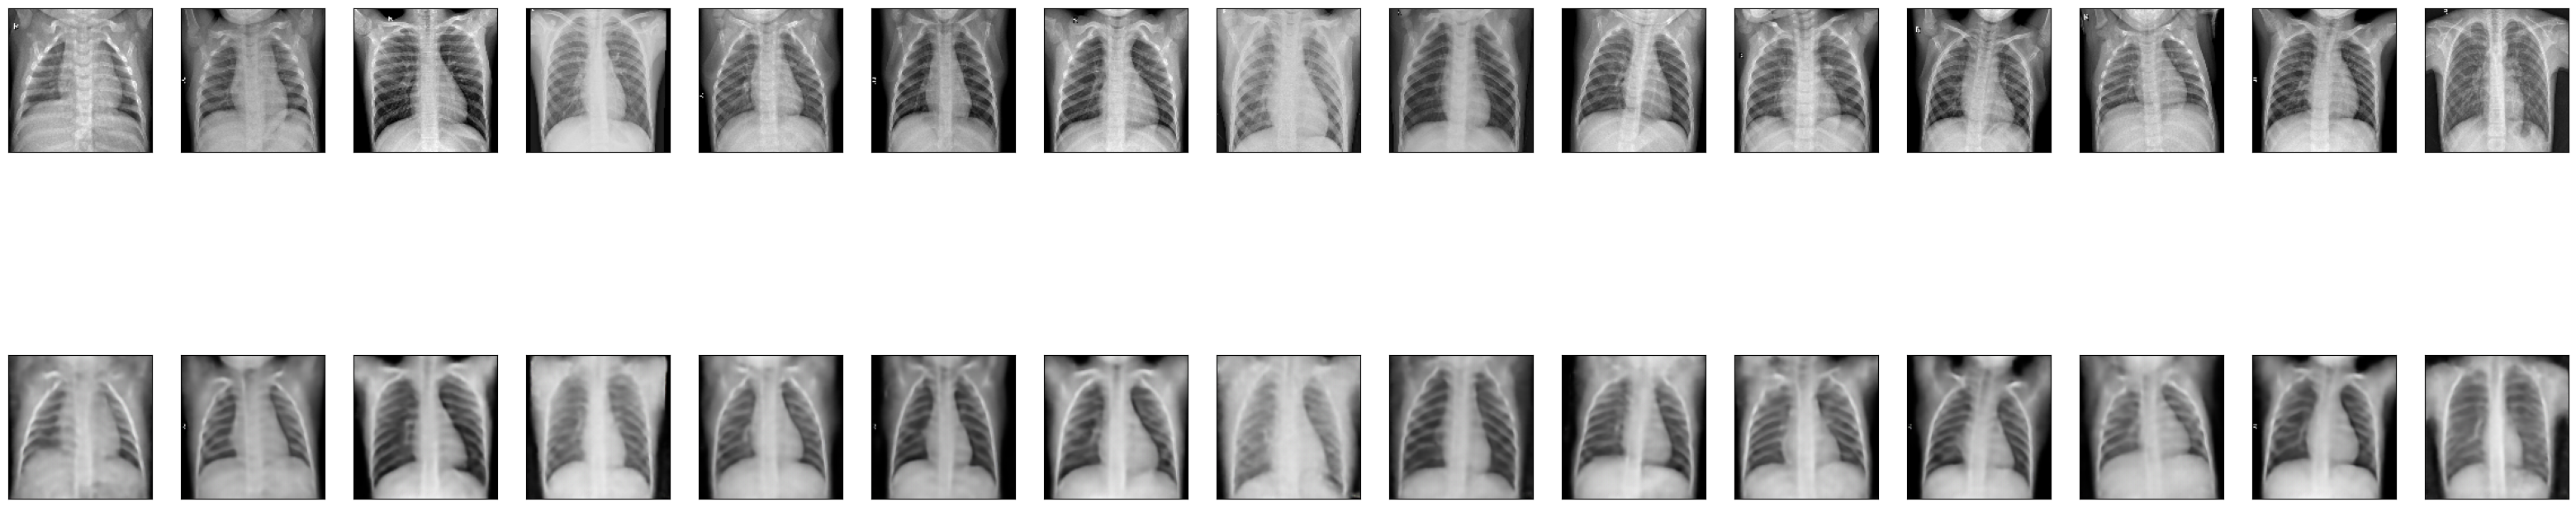

In [8]:
decoded_imgs = autoencoder.predict(X_test)

n = 15  
plt.figure(figsize=(40, 10))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step


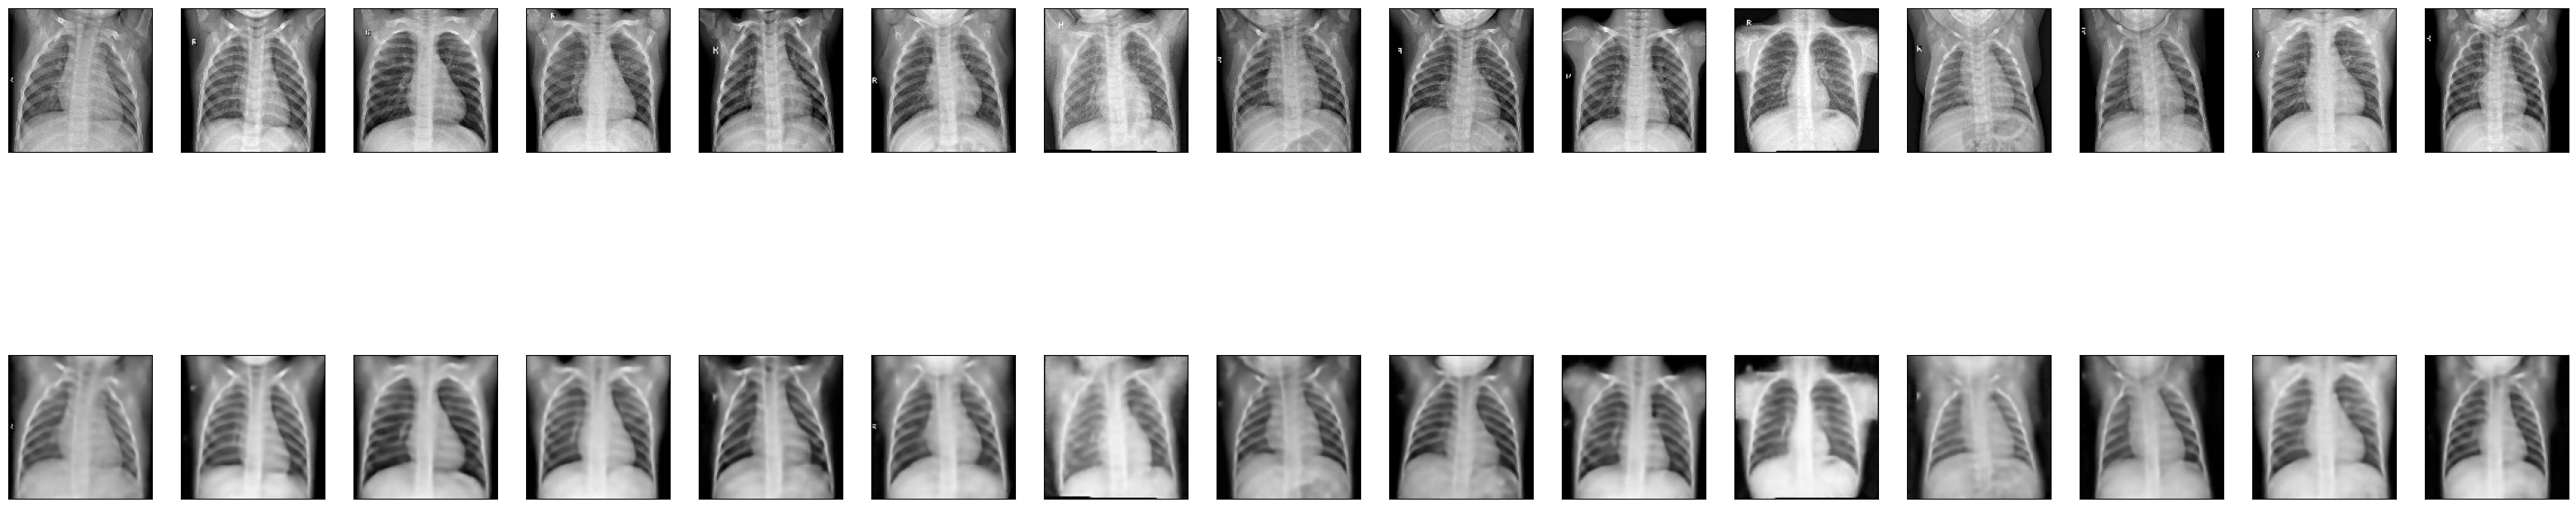

In [9]:
decoded_imgs = autoencoder.predict(X_train)

n = 15  
plt.figure(figsize=(40, 10))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_train[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


In [10]:
encoder = autoencoder.get_layer("Complex_Encoder")
encoder.summary() 

Model: "Complex_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 64, 64, 32)     │            896 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 64, 64, 32)     │            128 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 32, 32, 64)     │         18,496 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 32, 32, 64)     │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 32, 32, 64)     │         36,928 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 32, 32, 64)     │            256 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 32, 32, 64)     │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 32, 32, 64)     │         36,928 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 32, 32, 64)     │            256 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 32, 32, 64)     │              0 │ batch_normalization_1… │
│                           │                        │                │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 32, 32, 64)     │              0 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 16, 16, 128)    │         73,856 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 16, 16, 128)    │            512 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 16, 16, 128)    │        147,584 │ batch_normalization_4… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_5     │ (None, 16, 16, 128)    │            512 │ conv2d_5[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├──────────────────────

 Total params: 8,853,568 (33.77 MB)

 Trainable params: 8,852,352 (33.77 MB)

 Non-trainable params: 1,216 (4.75 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step
Feature Maps Shape: (1, 32, 32, 64)


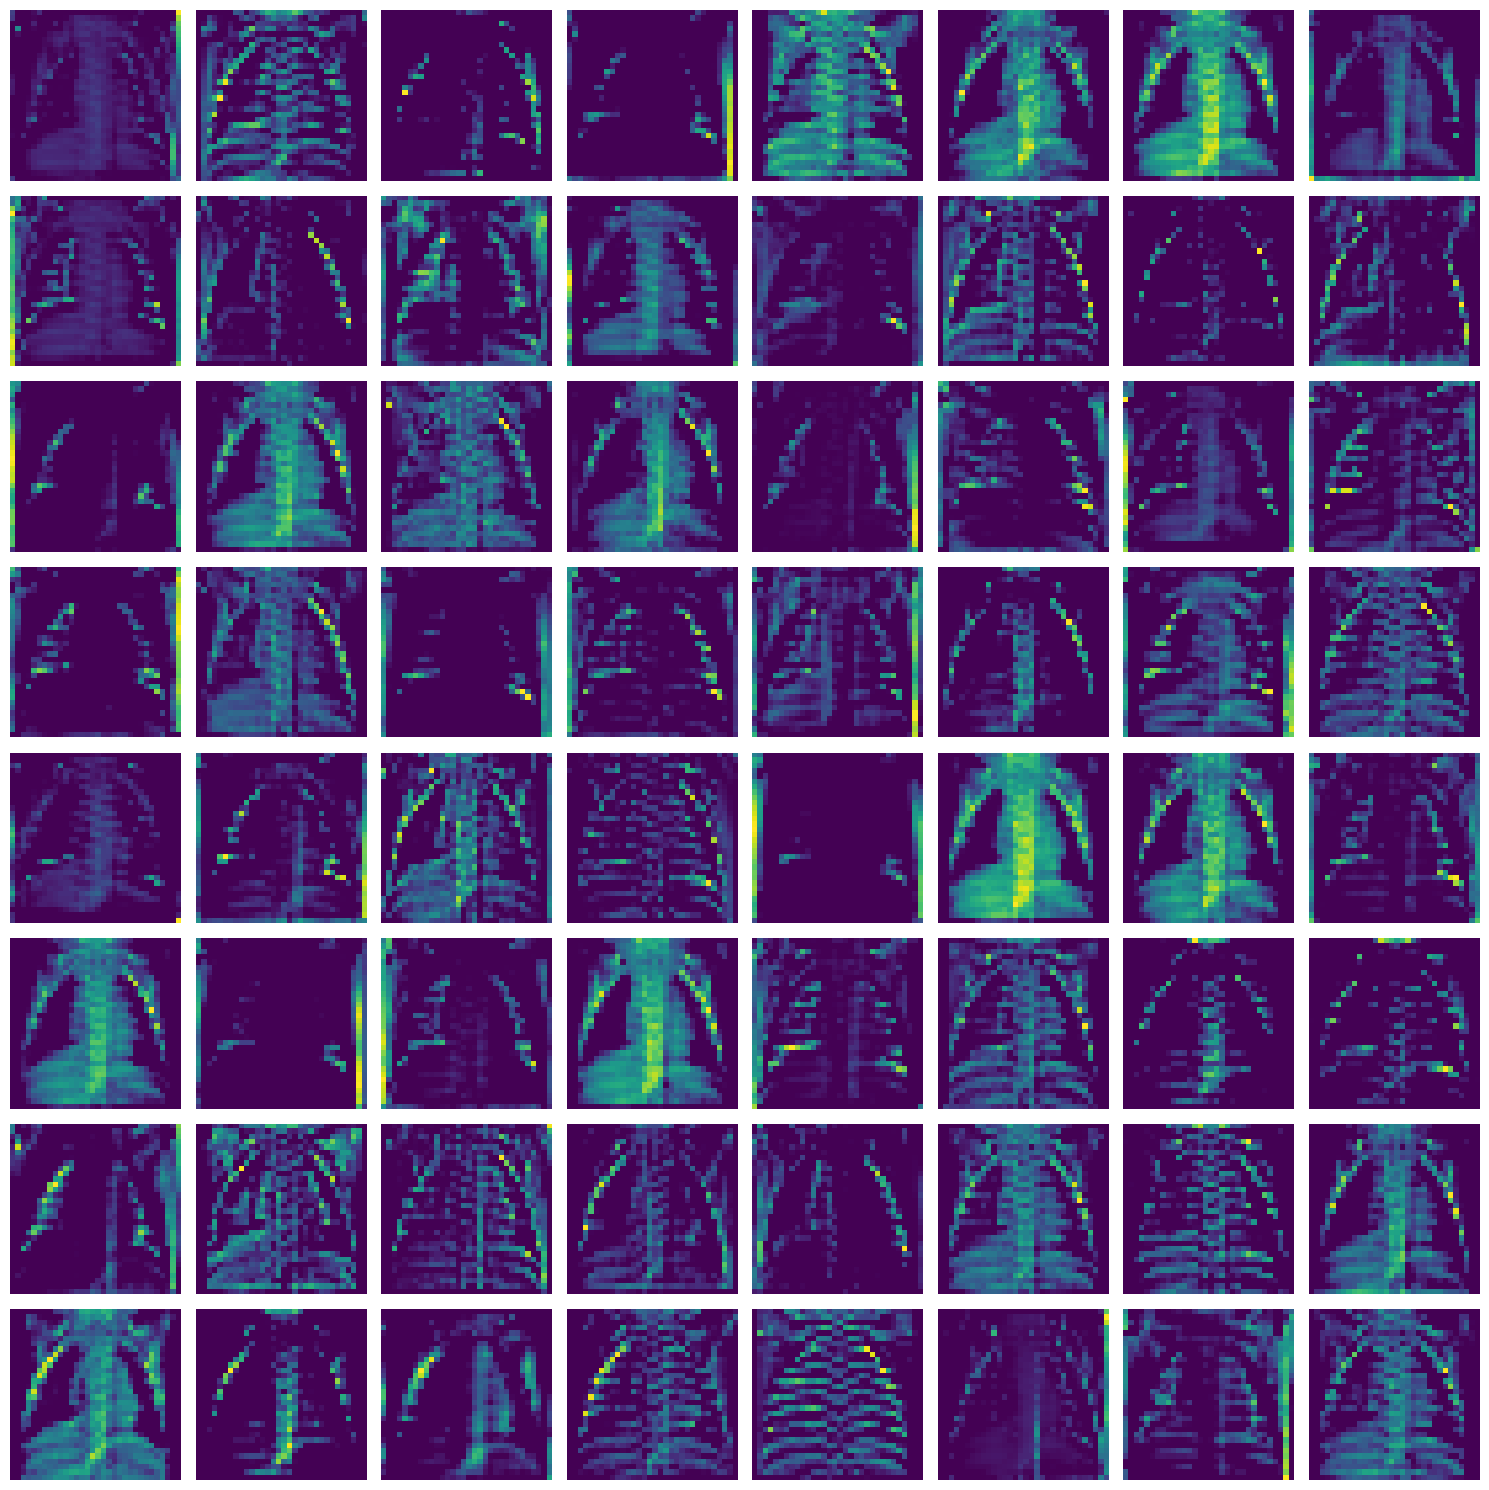

In [11]:
from keras.models import Model

conv_layer_name = "activation"
feature_map_model = Model(inputs=encoder.input, outputs=encoder.get_layer(conv_layer_name).output)

test_image = X_test[0:1] 
feature_maps = feature_map_model.predict(test_image)

print(f"Feature Maps Shape: {feature_maps.shape}")  

def plot_feature_maps(feature_maps):
    num_maps = feature_maps.shape[-1]  
    grid_size = int(np.ceil(np.sqrt(num_maps)))  

    plt.figure(figsize=(15, 15))
    for i in range(num_maps):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

plot_feature_maps(feature_maps)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 661ms/step
Feature Maps Shape: (1, 16, 16, 128)


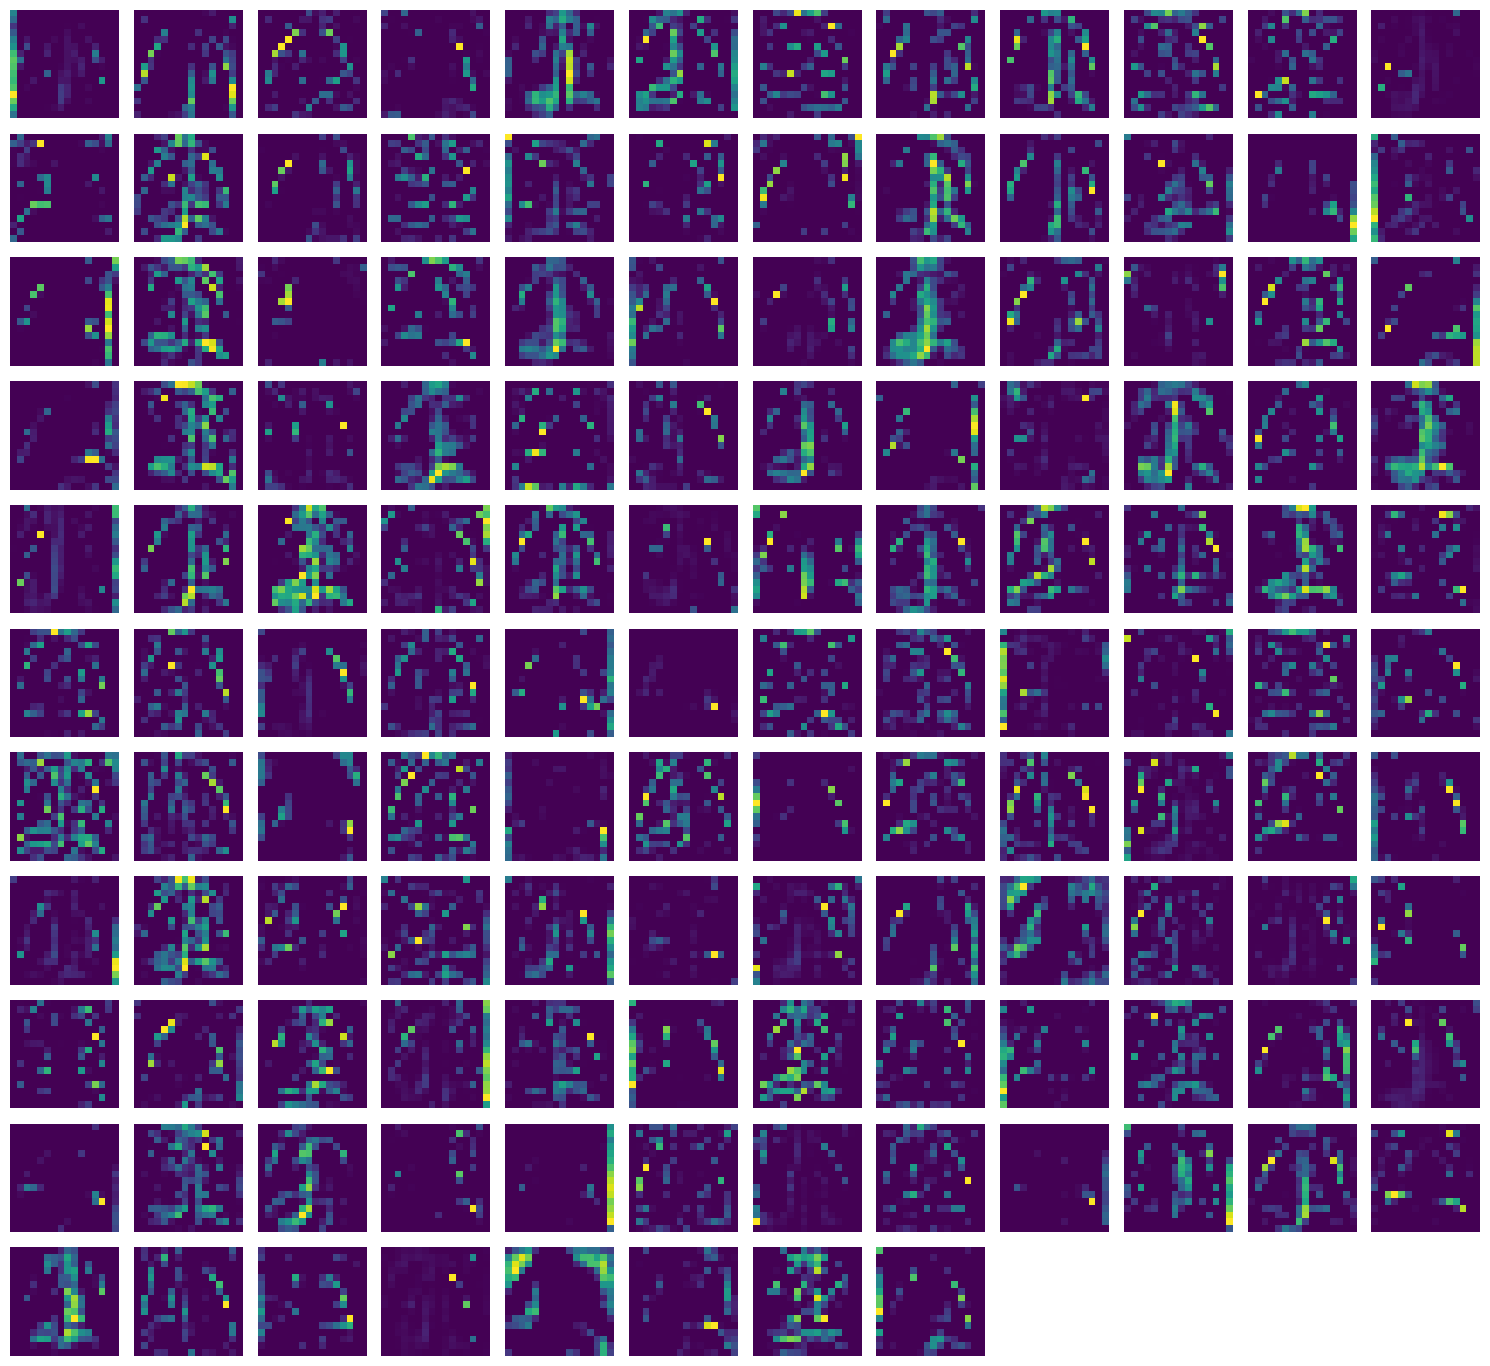

In [12]:
from keras.models import Model

conv_layer_name = "activation_1"
feature_map_model1 = Model(inputs=encoder.input, outputs=encoder.get_layer(conv_layer_name).output)

test_image = X_test[0:1] 
feature_maps = feature_map_model1.predict(test_image)

print(f"Feature Maps Shape: {feature_maps.shape}")  # Expected: (1, 16, 16, 128)

def plot_feature_maps(feature_maps):
    num_maps = feature_maps.shape[-1]  
    grid_size = int(np.ceil(np.sqrt(num_maps))) 

    plt.figure(figsize=(15, 15))
    for i in range(num_maps):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

plot_feature_maps(feature_maps)


In [13]:
import numpy as np
from tensorflow.keras.models import Model

conv_layer_name = "dense"
latent_model = Model(inputs=encoder.input, outputs=encoder.get_layer(conv_layer_name).output)

latent_vectors = latent_model.predict(X_test[:10])

for i, vector in enumerate(latent_vectors):
    print(f"Latent vector for test image {i + 1}:")
    print(vector)
    print("-" * 50)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 995ms/step
Latent vector for test image 1:
[0.00000000e+00 2.07935486e+01 2.33497620e+01 0.00000000e+00
 0.00000000e+00 6.16958427e+01 0.00000000e+00 0.00000000e+00
 0.00000000e+00 5.04796295e+01 1.22636375e+01 0.00000000e+00
 0.00000000e+00 0.00000000e+00 8.96812515e+01 0.00000000e+00
 6.78740463e+01 4.02627563e+00 1.33457733e+02 7.54012985e+01
 9.76970291e+00 0.00000000e+00 2.06965580e+01 0.00000000e+00
 7.97371216e+01 0.00000000e+00 7.26711197e+01 9.38391876e+01
 0.00000000e+00 0.00000000e+00 2.01783466e+01 0.00000000e+00
 2.63855782e+01 0.00000000e+00 0.00000000e+00 6.00470085e+01
 0.00000000e+00 0.00000000e+00 0.00000000e+00 7.04174614e+00
 0.00000000e+00 5.28446732e+01 1.04001389e+02 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.44317799e+01 0.00000000e+00 0.00000000e+00
 0.00000000e+00 2.04824200e+01 0.00000000e+00 0.00000000e+00
 0.00000000e+00 7.03637009e+01 9.80206108e+00 0.00000000e+00
 7.75570984e+0

In [14]:
decoder = autoencoder.get_layer("Complex_Decoder")
decoder.summary() 

Model: "Complex_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 256)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 32768)          │      8,421,376 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 16, 16, 128)    │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose          │ (None, 32, 32, 128)    │        147,584 │ reshape[0][0]          │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_7     │ (None, 32, 32, 128)    │            512 │ conv2d_transpose[0][0] │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 32, 32, 128)    │        147,584 │ batch_normalization_7… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_8     │ (None, 32, 32, 128)    │            512 │ conv2d_7[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 32, 32, 128)    │              0 │ batch_normalization_8… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 32, 32, 128)    │        147,584 │ dropout_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_9     │ (None, 32, 32, 128)    │            512 │ conv2d_8[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_2 (Add)               │ (None, 32, 32, 128)    │              0 │ batch_normalization_7… │
│                           │                        │                │ batch_normalization_9… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 32, 32, 128)    │              0 │ add_2[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_1        │ (None, 64, 64, 64)     │         73,792 │ activation_2[0][0]     │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_10    │ (None, 64, 64, 64)     │            256 │ conv2d_transpose_1[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 64, 64, 64)     │         36,928 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1

 Total params: 9,033,539 (34.46 MB)

 Trainable params: 9,032,323 (34.46 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [15]:
latent_vectors.shape

(10, 256)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step


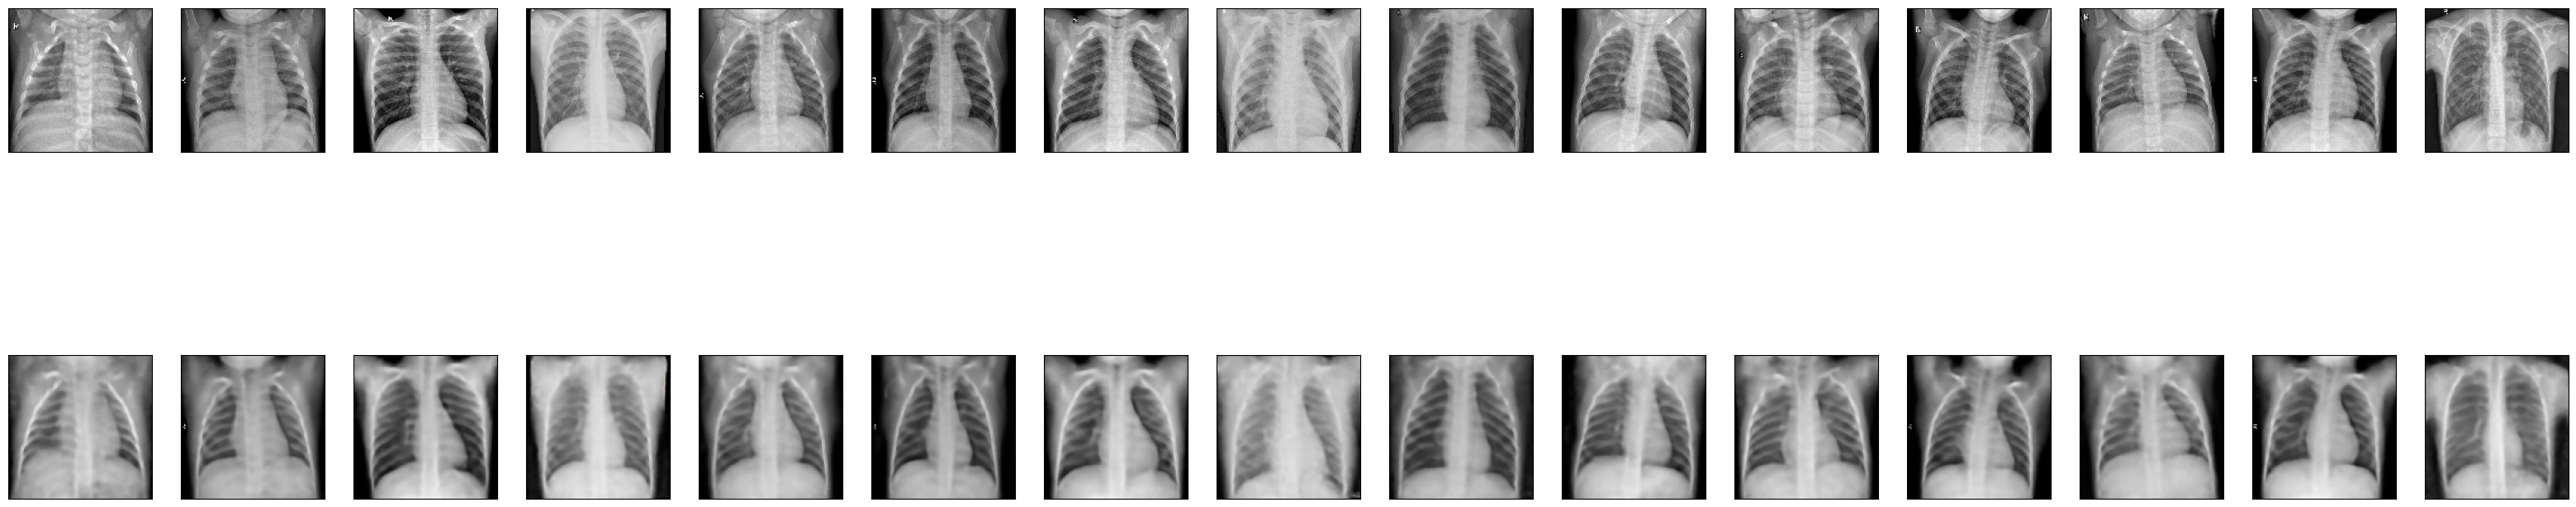

In [16]:
encoder = autoencoder.get_layer("Complex_Encoder")  
decoder = autoencoder.get_layer("Complex_Decoder")  

encoded_data = encoder.predict(X_test)

y_test = decoder.predict(encoded_data)

n = 15 
plt.figure(figsize=(40, 10))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(y_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [17]:
encoded_data.shape

(315, 256)

In [18]:
from tensorflow.keras import layers, models

def res_block(x, filters, use_bn=True, dropout_rate=0.0):
    shortcut = x
    x = layers.Conv2D(filters, (3, 3), padding="same", activation="relu")(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    if dropout_rate > 0.0:
        x = layers.Dropout(dropout_rate)(x)
    x = layers.Conv2D(filters, (3, 3), padding="same", activation=None)(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Add()([shortcut, x])
    x = layers.Activation("relu")(x)
    return x

def build_encoder(input_shape=(128, 128, 3)):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), strides=2, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 64, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2D(128, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 128, use_bn=True, dropout_rate=0.1)

    # No Flatten, keeping feature maps
    return models.Model(inputs, x, name="Encoder")

def build_decoder(target_shape=(128, 128, 3)):
    inputs = layers.Input(shape=(16, 16, 128))  # Assuming feature maps size here

    x = layers.Conv2DTranspose(128, (3, 3), strides=2, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 128, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2DTranspose(64, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = res_block(x, 64, use_bn=True, dropout_rate=0.1)

    x = layers.Conv2DTranspose(32, (3, 3), strides=2, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2DTranspose(target_shape[-1], (3, 3), padding="same", activation="sigmoid")(x)

    return models.Model(inputs, x, name="Decoder")

In [19]:
def build_autoencoder(input_shape=(128, 128, 3)):
    encoder = build_encoder(input_shape)
    decoder = build_decoder(target_shape=input_shape)

    inputs = layers.Input(shape=input_shape)
    feature_maps = encoder(inputs)  # Outputs feature maps
    reconstructed = decoder(feature_maps)  # Decoder takes feature maps as input

    autoencoder = models.Model(inputs, reconstructed, name="Autoencoder")
    autoencoder.compile(optimizer="adam", loss="mean_squared_error")
    return autoencoder

autoencoder = build_autoencoder(input_shape=(128, 128, 3))
autoencoder.summary()

# Training the autoencoder
autoencoder.fit(
    X_train, X_train,
    validation_data=(X_test, X_test),
    epochs=67,
    batch_size=16,
) 


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Encoder (Functional)                 │ (None, 16, 16, 128)         │         464,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Decoder (Functional)                 │ (None, 128, 128, 3)         │         612,163 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,076,867 (4.11 MB)

 Trainable params: 1,074,435 (4.10 MB)

 Non-trainable params: 2,432 (9.50 KB)

Epoch 1/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 173ms/step - loss: 0.0260 - val_loss: 0.0558
Epoch 2/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0035 - val_loss: 0.0420
Epoch 3/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0026 - val_loss: 0.0271
Epoch 4/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0024 - val_loss: 0.0133
Epoch 5/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0020 - val_loss: 0.0064
Epoch 6/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0020 - val_loss: 0.0029
Epoch 7/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0020 - val_loss: 0.0018
Epoch 8/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 9/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0017 - val_loss: 0.0018
Epoch 10/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0017 - val_loss: 0.0021
Epoch 11/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0016 - val_loss: 0.0017
Epoch 12/67
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step


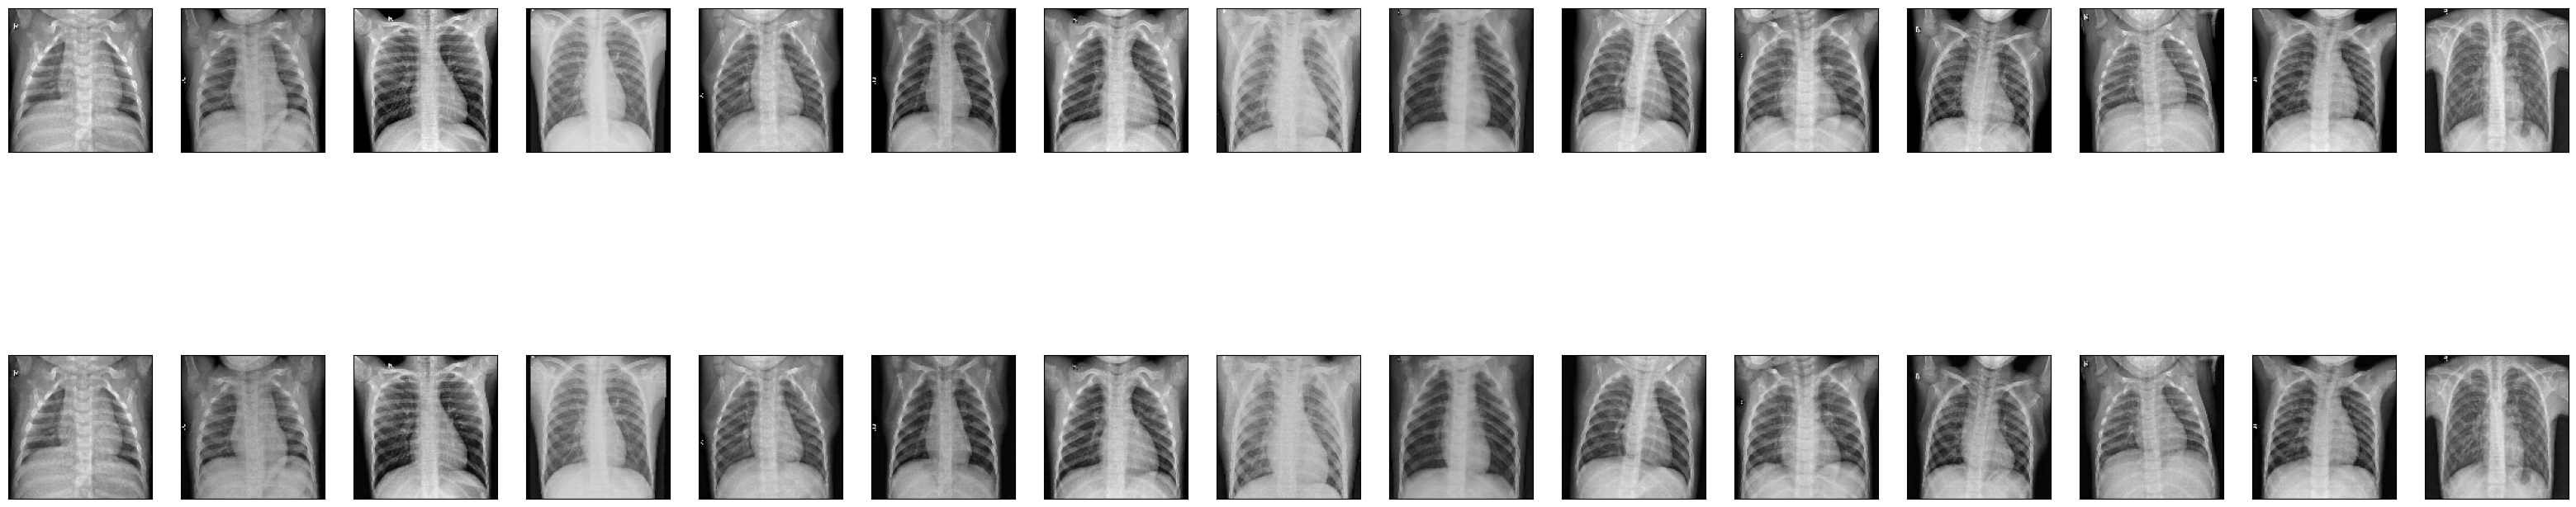

In [20]:

# Predicting decoded images
decoded_imgs = autoencoder.predict(X_test)

# Displaying original and reconstructed images
n = 15  
plt.figure(figsize=(40, 10))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


In [ ]:
X_train, X_test = train_test_split(images, test_size=0.2, random_state=42)

In [ ]:
encoder = autoencoder.get_layer("Encoder")
encoder.summary() 

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


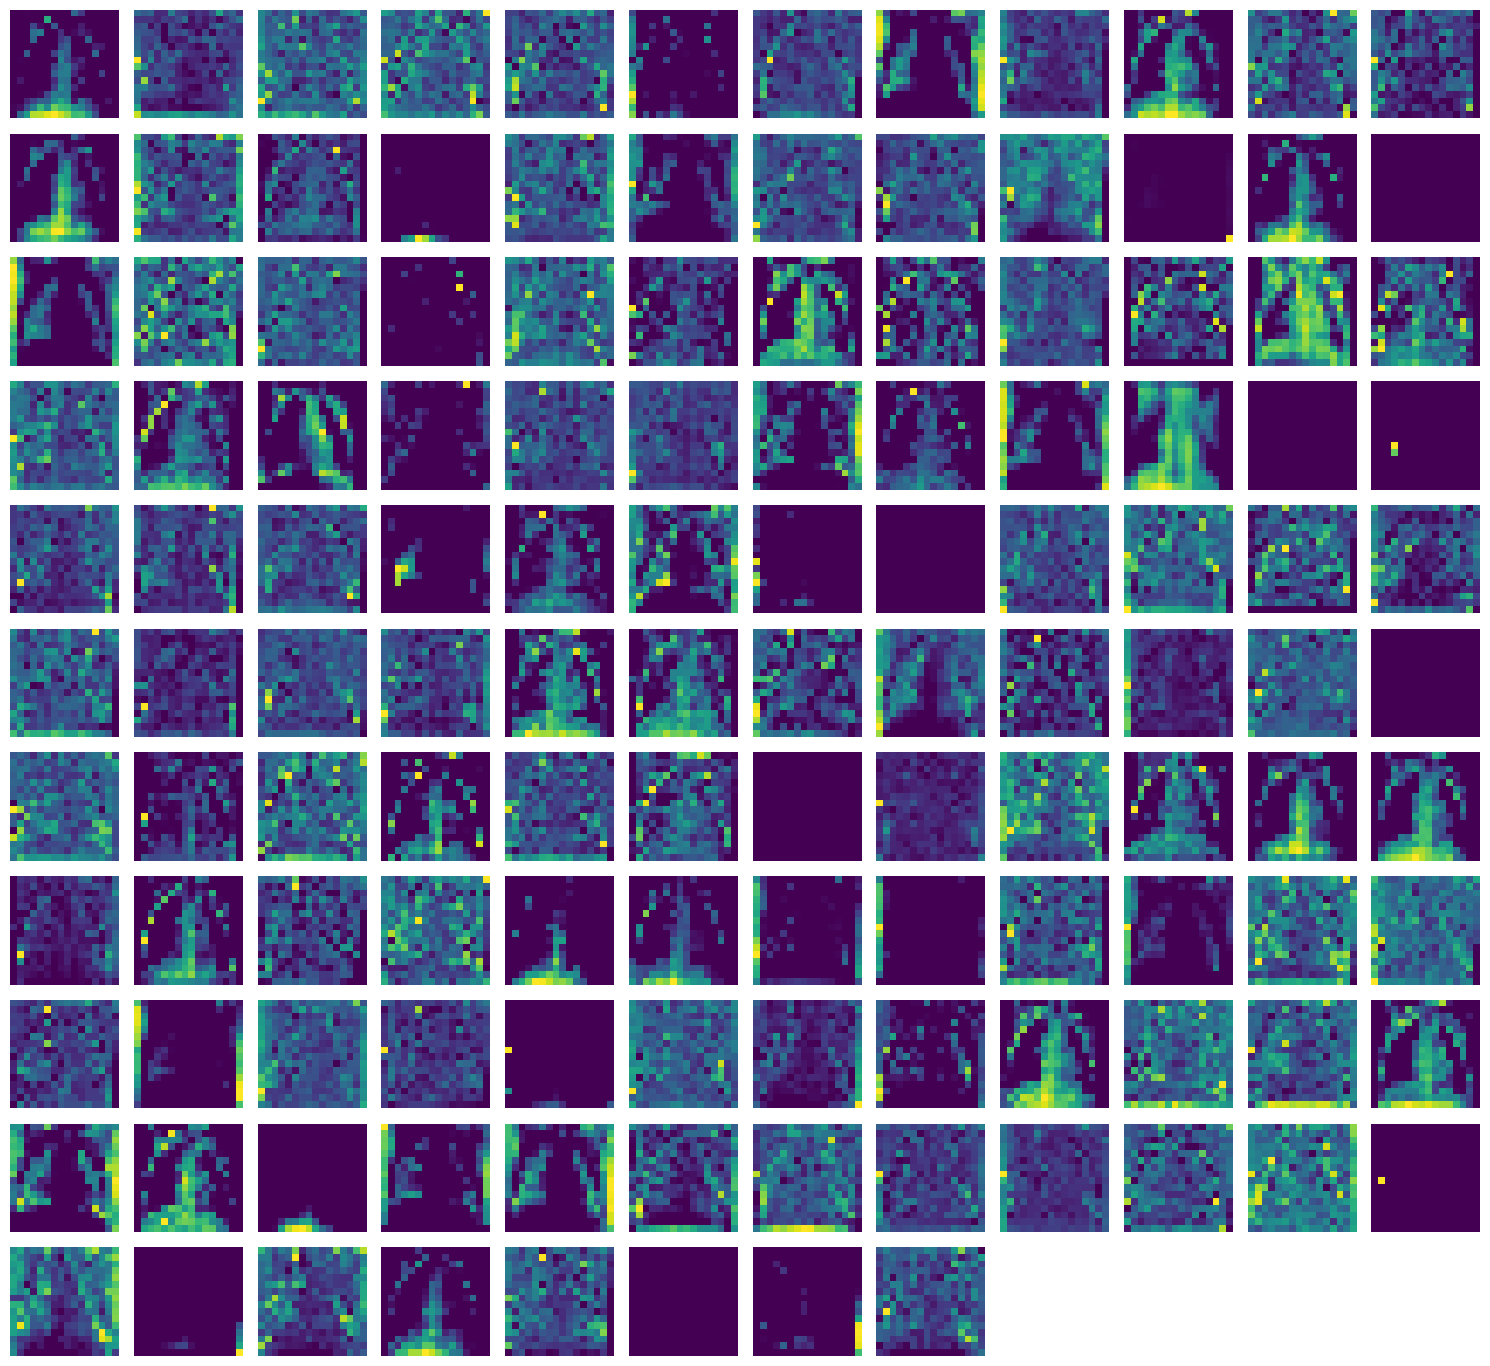

In [30]:
fmaps = encoder.predict(X_train)

def plot_feature_maps(feature_maps):
    num_maps = feature_maps.shape[-1]  
    grid_size = int(np.ceil(np.sqrt(num_maps))) 

    plt.figure(figsize=(15, 15))
    for i in range(num_maps):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(feature_maps[0, :, :, i], cmap="viridis")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

plot_feature_maps(fmaps)

In [26]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, Add, UpSampling2D, Dropout
from tensorflow.keras.models import Model

def distortion_encoder(input_shape=(16, 16, 128)):
    input_layer = Input(shape=input_shape)
    x = Conv2D(128, (3, 3), padding='same', activation='relu')(input_layer)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(16, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(8, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(1, (3, 3), padding='same', activation='sigmoid')(x)  # Producing a highly distorted grayscale image
    return Model(input_layer, x, name="Distortion_Encoder")

def feature_decoder(input_shape=(16, 16, 1)):
    encoded_input = Input(shape=input_shape)
    y = Conv2D(8, (3, 3), padding='same', activation='relu')(encoded_input)
    y = BatchNormalization()(y)
    y = Conv2D(16, (3, 3), padding='same', activation='relu')(y)
    y = BatchNormalization()(y)
    y = Conv2D(32, (3, 3), padding='same', activation='relu')(y)
    y = BatchNormalization()(y)
    y = Conv2D(64, (3, 3), padding='same', activation='relu')(y)
    y = BatchNormalization()(y)
    y = Conv2D(128, (3, 3), padding='same', activation='relu')(y)
    y = BatchNormalization()(y)
    y = Conv2D(128, (3, 3), padding='same', activation='sigmoid')(y)  # Reconstructing the feature map
    return Model(encoded_input, y, name="Feature_Decoder")

def build_autoencoder():
    encoder = distortion_encoder()
    decoder = feature_decoder()
    input_img = Input(shape=(16, 16, 128))
    encoded = encoder(input_img)
    decoded = decoder(encoded)
    autoencoder = Model(input_img, decoded, name="Autoencoder")
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

autoencoder = build_autoencoder()
autoencoder.summary()


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)          │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Distortion_Encoder (Functional)      │ (None, 16, 16, 1)           │         246,689 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Feature_Decoder (Functional)         │ (None, 16, 16, 128)         │         246,816 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 493,505 (1.88 MB)

 Trainable params: 492,513 (1.88 MB)

 Non-trainable params: 992 (3.88 KB)